## 3DoF Entry VTOL w/o Aoa SCP

Imports

In [1]:
import importlib
import numpy as np

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
from trajopt.core.trajectory_analyzer import TrajectoryAnalyzer
np.random.seed(0)  # for reproducibility

setup problem and run SCP

In [2]:
# create trajectroy analyzer object
trajopt = TrajectoryAnalyzer("trajopt.yaml")

# run SCP
trajopt.solve()

constraints:
  0: dynamics: dynamics
  1: initial_state: equality_bc
  2: final_state: equality_bc
  3: state_limits: box
  4: bank_angle_limit: box
  5: bank_angle_rate_limit: control_rate_limit
  6: max_Q: nonconvex_inequality
  7: max_q: nonconvex_inequality
  8: max_load: nonconvex_inequality
costs:
  0: min_terminal_velocity: terminal_state
scales: 
d: 6378137.0000, t: 806.3293, m: 104305.0000, v: 7910.0900, a: 9.8100, f: 1023232.0500, fdot: 1269.0003, mom: 6526314197690.8486, momdot: 8093857616.8560, ang: 57.2958, angv: 0.0711, none: 1.0000
constraints nondimmed!
constraints convexified!
costs nondimmed!
costs convexified!
Initial guess time: 0.3156508340034634 seconds
initial nondim state: 
[ 1.01567856  0.          0.          0.94183505 -0.00872665  0.        ]
Cost initial: 0.0
total number of parameters: 5102
--------------------------------------------------------------------------------------------------------------------------------------------------------
---------------

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    01036.5   |   0007.8  |   0746.5   |   -3.2    |      -12.0      |    -02.0    |     -12.0   |    optimal    |   1721.98   |   0.0
     02     |    00005.6   |   0006.5  |   0000.8   |   -2.3    |      -12.0      |    -03.1    |     -12.0   |    optimal    |   1805.68   |   0.0
     03     |    00005.3   |   0007.4  |   0000.6   |   -2.8    |      -12.0      |    -02.7    |     -12.0   |    optimal    |   1657.47   |   0.0
     04     |    00005.0   |   0006.3  |   0000.6   |   -3.1    |      -12.0      |    -02.8    |     -12.0   |    optimal    |   1627.04   |   0.0
     05     |    00005.0   |   0006.3  |   0000.5   |   -2.8    |      -12.0      |    -04.7    |     -12.0   |    optimal    |   1788.25   |   0.0
     06     |    00004.7   |   0005.4  |   0000.5   |   -3.3    |      -12.0      |    -03.8    |     -12.0   |    optimal    |   1755.69   |   0.0
     07     |    00004.8   |   0005.8  |   0000.6   |   -3.6    |      -12.0      |    -04.7    |     -12.0   | 

mc analysis

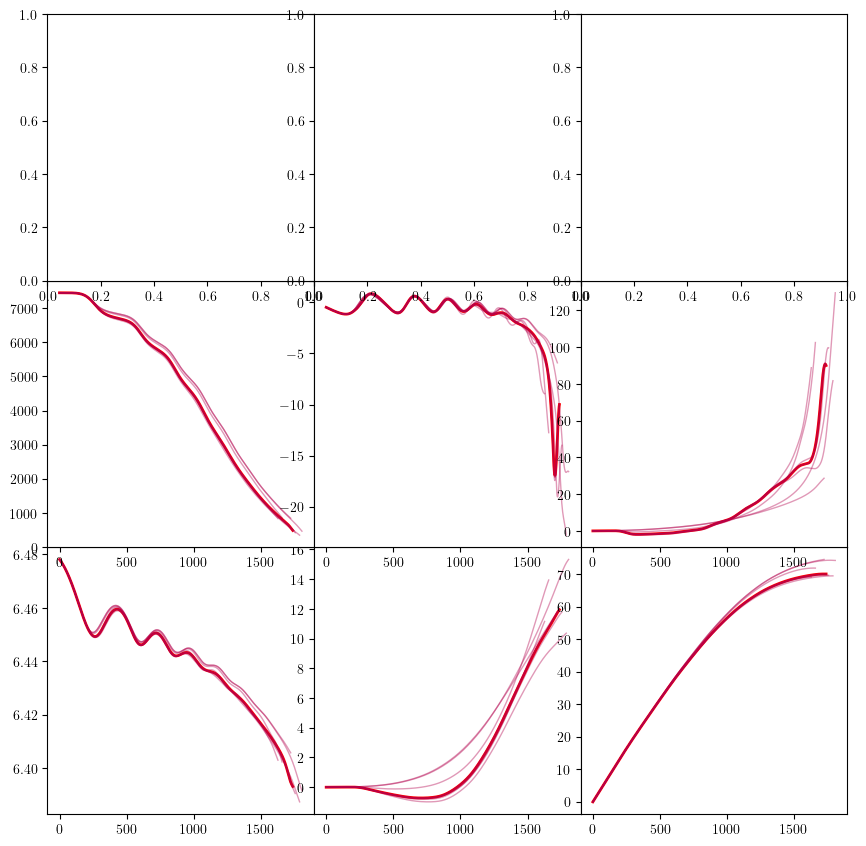

In [3]:
scenario_data = trajopt.analyze()

100000.0
14996.315244980156


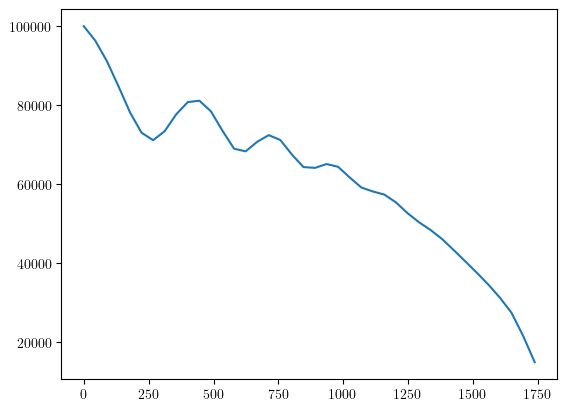

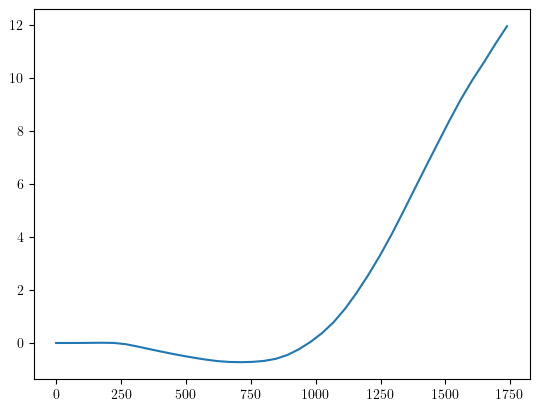

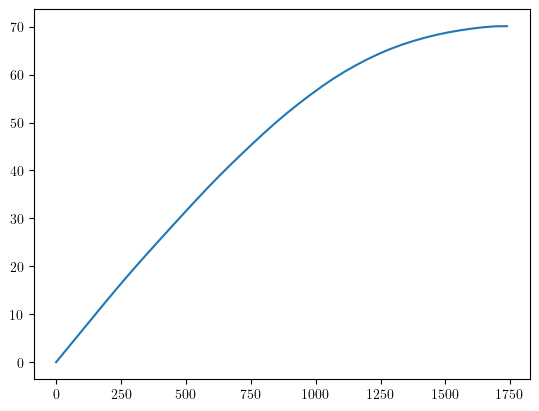

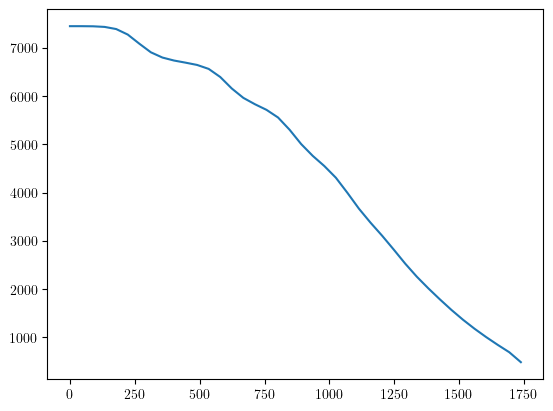

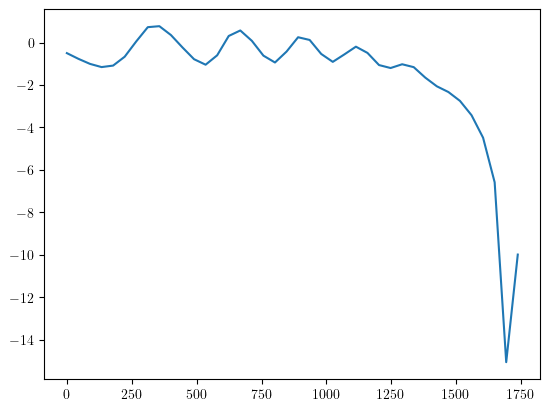

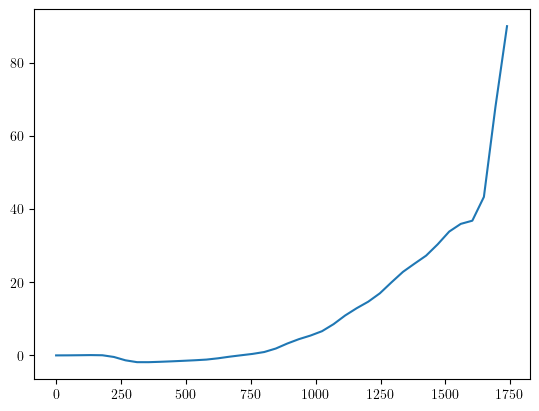

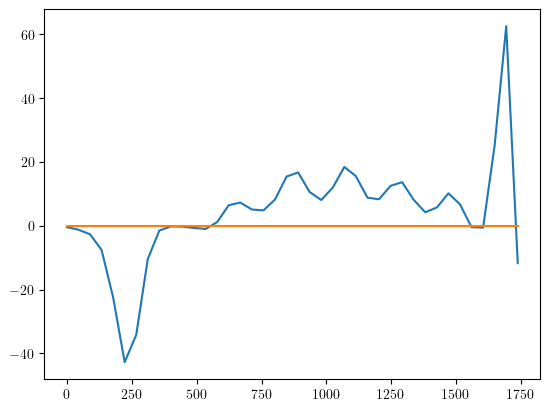

In [4]:
import matplotlib.pyplot as plt

plt.figure()

nominal_run = scenario_data['autotune']['mc_data'][0]
solution = nominal_run['iters'][-1]

# print(nominal_run['params'].keys())
params = nominal_run['params']

# print(solution.keys())

t_opt = solution['t_opt']
z_opt = solution['z_opt']
nu_opt = solution['nu_opt']



print(params['mission']['constraints'][1]['x'][0] - params['mission']['planet']['r'])

print(z_opt[-1, 0] - params['mission']['planet']['r'])

plt.plot(t_opt, z_opt[:, 0] - params['mission']['planet']['r'])
plt.figure()
plt.plot(t_opt, z_opt[:, 1])
plt.figure()
plt.plot(t_opt, z_opt[:, 2])
plt.figure()
plt.plot(t_opt, z_opt[:, 3])
plt.figure()
plt.plot(t_opt, z_opt[:, 4])
plt.figure()
plt.plot(t_opt, z_opt[:, 5])


plt.figure()
plt.plot(t_opt, nu_opt[:, 0])
plt.plot(t_opt, nu_opt[:, 1])


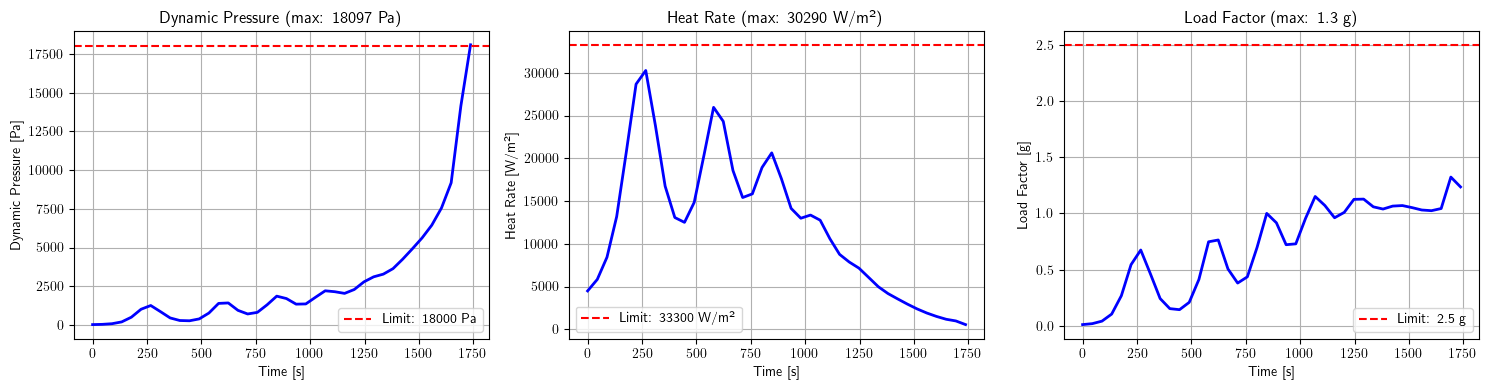

Max dynamic pressure: 18097 Pa (limit: 18000 Pa)
Max heat rate: 30290 W/m² (limit: 33300 W/m²)
Max load factor: 1.32 g (limit: 2.50 g)


In [5]:
# Simple plotting for max_Q, max_q, and max_load
import matplotlib.pyplot as plt
import numpy as np

# Get solution data
nominal_run = scenario_data['autotune']['mc_data'][0]
solution = nominal_run['iters'][-1]
params = nominal_run['params']

t_opt = solution['t_opt']
z_opt = solution['z_opt']
nu_opt = solution['nu_opt']

# Extract parameters
r_planet = params['mission']['planet']['r']
rho0 = params['mission']['planet']['rho']
H = params['mission']['planet']['H']
kQ = params['mission']['vehicle']['kQ']
sref = params['mission']['vehicle']['sref']
mass = params['mission']['vehicle']['mass']
g = params['mission']['planet']['g']

# Compute loads along trajectory
N = len(t_opt)
q_vals = np.zeros(N)      # dynamic pressure
Q_vals = np.zeros(N)      # heat rate
load_vals = np.zeros(N)   # load factor (g's)

for k in range(N):
    r = z_opt[k, 0]
    v = z_opt[k, 3]
    h = r - r_planet
    
    # Atmosphere model (exponential)
    rho = rho0 * np.exp(-h / H)
    
    # Dynamic pressure
    q_vals[k] = 0.5 * rho * v**2
    
    # Heat rate
    Q_vals[k] = kQ * np.sqrt(rho) * v**3
    
    # Aero coefficients (simplified - using velocity-dependent model)
    kl1 = -0.041065; kl2 = 0.016292; kl3 = 0.0002602
    kd1 = 0.080505; kd2 = -0.03026; kd3 = 0.86495
    kalph = 0.20705 / (340**2); vlim = 4570; alphlim_deg = 40
    
    Kl1 = kl1 + kl2 * alphlim_deg + kl3 * alphlim_deg**2
    Kl2 = -kl2 * kalph - 2 * kl3 * alphlim_deg * kalph
    Kl3 = kl3 * kalph**2
    
    v_sat = min(v, vlim)
    Cl = Kl1 + Kl2 * (v_sat - vlim)**2 + Kl3 * (v_sat - vlim)**4
    Cd = kd1 + kd2 * Cl + kd3 * Cl**2
    
    L = (0.5 / mass) * rho * sref * Cl * v**2
    D = (0.5 / mass) * rho * sref * Cd * v**2
    load_vals[k] = np.sqrt(L**2 + D**2) / g  # in g's

# Get constraint limits
max_Q_limit = params['mission']['constraints'][6]['max_val']
max_q_limit = params['mission']['constraints'][7]['max_val']
max_load_limit = params['mission']['constraints'][8]['max_val'] / 9.81

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dynamic pressure (q)
axes[0].plot(t_opt, q_vals, 'b-', linewidth=2)
axes[0].axhline(y=max_q_limit, color='r', linestyle='--', label=f'Limit: {max_q_limit:.0f} Pa')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Dynamic Pressure [Pa]')
axes[0].set_title(f'Dynamic Pressure (max: {np.max(q_vals):.0f} Pa)')
axes[0].legend()
axes[0].grid(True)

# Heat rate (Q)
axes[1].plot(t_opt, Q_vals, 'b-', linewidth=2)
axes[1].axhline(y=max_Q_limit, color='r', linestyle='--', label=f'Limit: {max_Q_limit:.0f} W/m²')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Heat Rate [W/m²]')
axes[1].set_title(f'Heat Rate (max: {np.max(Q_vals):.0f} W/m²)')
axes[1].legend()
axes[1].grid(True)

# Load factor
axes[2].plot(t_opt, load_vals, 'b-', linewidth=2)
axes[2].axhline(y=max_load_limit, color='r', linestyle='--', label=f'Limit: {max_load_limit:.1f} g')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Load Factor [g]')
axes[2].set_title(f'Load Factor (max: {np.max(load_vals):.1f} g)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Max dynamic pressure: {np.max(q_vals):.0f} Pa (limit: {max_q_limit:.0f} Pa)")
print(f"Max heat rate: {np.max(Q_vals):.0f} W/m² (limit: {max_Q_limit:.0f} W/m²)")
print(f"Max load factor: {np.max(load_vals):.2f} g (limit: {max_load_limit:.2f} g)")